<a href="https://colab.research.google.com/github/DesislavaLebessis/rupite-climate-analysis/blob/main/rupite_climate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.0/711.0 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 102.3 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [3]:
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
from retry_requests import retry
from scipy import stats
import matplotlib.pyplot as plt
import datetime

print("Bibliotheken geladen!")

Bibliotheken geladen!


In [4]:
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)
url = "https://archive-api.open-meteo.com/v1/archive"

def lade_klimadaten(lat, lon, name):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "1950-01-01",
        "end_date": "2025-01-01",
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum"
        ],
        "timezone": "Europe/Sofia"
    }
    response = openmeteo.weather_api(url, params=params)[0]
    daily = response.Daily()
    dates = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s"),
        end=pd.to_datetime(daily.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    )
    df = pd.DataFrame({
        "tmax": daily.Variables(0).ValuesAsNumpy(),
        "tmin": daily.Variables(1).ValuesAsNumpy(),
        "prcp": daily.Variables(2).ValuesAsNumpy()
    }, index=dates)
    df["tmean"] = (df["tmax"] + df["tmin"]) / 2
    df = df[df.index >= "1950-01-01"]
    df = df[df.index < "2025-01-01"]
    print(f"{name}: {len(df)} Tage geladen")
    return df

print("Setup abgeschlossen!")

Setup abgeschlossen!


In [6]:
print("Lade Klimadaten...")
df_rupite = lade_klimadaten(41.47, 23.22, "Rupite")
df_blago  = lade_klimadaten(42.01, 23.09, "Blagoevgrad")
df_sofia  = lade_klimadaten(42.70, 23.32, "Sofia")
print("Alle Daten erfolgreich geladen!")

Lade Klimadaten...
Rupite: 27394 Tage geladen
Blagoevgrad: 27394 Tage geladen
Sofia: 27394 Tage geladen
Alle Daten erfolgreich geladen!


In [7]:
rupite_j = df_rupite.resample("YE").mean()["1950":"2024"]
blago_j  = df_blago.resample("YE").mean()["1950":"2024"]
sofia_j  = df_sofia.resample("YE").mean()["1950":"2024"]

jahre_real = rupite_j.index.year
jahre = np.arange(len(rupite_j))

print("Jahreswerte berechnet!")
print(rupite_j.head(3))

Jahreswerte berechnet!
                 tmax       tmin      prcp      tmean
1950-12-31  19.757671  10.277123  1.708493  15.017398
1951-12-31  19.302465  10.957534  1.692329  15.130000
1952-12-31  19.694864  11.249508  1.863661  15.472187


In [8]:
s_r, a_r, _, p_r, _ = stats.linregress(jahre, rupite_j["tmean"])
s_b, a_b, _, p_b, _ = stats.linregress(jahre, blago_j["tmean"])
s_s, a_s, _, p_s, _ = stats.linregress(jahre, sofia_j["tmean"])

print("=== ANALYSE 1: ERWAERMUNGSTREND ===")
print(f"Rupite:       +{s_r*10:.2f} Grad pro Jahrzehnt (p={p_r:.3f})")
print(f"Blagoevgrad:  +{s_b*10:.2f} Grad pro Jahrzehnt (p={p_b:.3f})")
print(f"Sofia:        +{s_s*10:.2f} Grad pro Jahrzehnt (p={p_s:.3f})")

=== ANALYSE 1: ERWAERMUNGSTREND ===
Rupite:       +0.18 Grad pro Jahrzehnt (p=0.000)
Blagoevgrad:  +0.19 Grad pro Jahrzehnt (p=0.000)
Sofia:        +0.22 Grad pro Jahrzehnt (p=0.000)


In [9]:
def klimasprung(daten, name):
    vor  = daten[daten.index.year < 1987]["tmean"].mean()
    nach = daten[daten.index.year >= 1987]["tmean"].mean()
    print(f"{name}: vor 1987 = {vor:.2f} Grad | nach 1987 = {nach:.2f} Grad | Sprung = +{nach-vor:.2f} Grad")

print("=== ANALYSE 2: KLIMABRUCH 1987 ===")
klimasprung(rupite_j, "Rupite      ")
klimasprung(blago_j,  "Blagoevgrad ")
klimasprung(sofia_j,  "Sofia       ")

=== ANALYSE 2: KLIMABRUCH 1987 ===
Rupite      : vor 1987 = 13.86 Grad | nach 1987 = 14.69 Grad | Sprung = +0.82 Grad
Blagoevgrad : vor 1987 = 12.19 Grad | nach 1987 = 13.00 Grad | Sprung = +0.81 Grad
Sofia       : vor 1987 = 10.18 Grad | nach 1987 = 11.08 Grad | Sprung = +0.90 Grad


In [10]:
frost_r = (df_rupite["tmin"] < 0).resample("YE").sum()["1950":"2024"]
frost_b = (df_blago["tmin"] < 0).resample("YE").sum()["1950":"2024"]
frost_s = (df_sofia["tmin"] < 0).resample("YE").sum()["1950":"2024"]

print("=== ANALYSE 3: FROSTTAGE ===")
print(f"Rupite:       {frost_r.mean():.1f} Tage/Jahr")
print(f"Blagoevgrad:  {frost_b.mean():.1f} Tage/Jahr")
print(f"Sofia:        {frost_s.mean():.1f} Tage/Jahr")

=== ANALYSE 3: FROSTTAGE ===
Rupite:       46.7 Tage/Jahr
Blagoevgrad:  71.4 Tage/Jahr
Sofia:        92.9 Tage/Jahr


In [11]:
def fruehlingsbeginn(df_city, name):
    ergebnisse = []
    for jahr in range(1950, 2025):
        daten = df_city[df_city.index.year == jahr]
        fruehjahr = daten[
            (daten.index.month >= 2) &
            (daten.index.month <= 5)
        ]
        warm = fruehjahr[fruehjahr["tmean"] > 10]
        if len(warm) > 0:
            ergebnisse.append({
                "jahr": jahr,
                "tag": warm.index[0].dayofyear
            })
    df_result = pd.DataFrame(ergebnisse).set_index("jahr")
    tag = df_result["tag"].mean()
    datum = datetime.date(2024, 1, 1) + datetime.timedelta(days=int(tag)-1)
    print(f"{name}: Tag {tag:.0f} ({datum.strftime('%d. %B')})")
    return df_result

print("=== ANALYSE 4: FRUEHLINGSBEGINN ===")
fruehling_r = fruehlingsbeginn(df_rupite, "Rupite      ")
fruehling_b = fruehlingsbeginn(df_blago,  "Blagoevgrad ")
fruehling_s = fruehlingsbeginn(df_sofia,  "Sofia       ")

=== ANALYSE 4: FRUEHLINGSBEGINN ===
Rupite      : Tag 55 (23. February)
Blagoevgrad : Tag 66 (05. March)
Sofia       : Tag 77 (17. March)


In [12]:
differenz = rupite_j["tmean"].values - blago_j["tmean"].values
s_d, a_d, _, p_d, _ = stats.linregress(jahre, differenz)

print("=== ANALYSE 5: GEOTHERMIE EFFEKT UEBER ZEIT ===")
print(f"Trend Differenz:     {s_d*10:.3f} Grad pro Jahrzehnt")
print(f"P-Wert:              {p_d:.4f}")
print(f"Differenz 1950-1960: {differenz[:10].mean():.2f} Grad")
print(f"Differenz 2014-2024: {differenz[-10:].mean():.2f} Grad")
if p_d < 0.05:
    print("Statistisch signifikant!")
else:
    print("Nicht signifikant - Effekt bleibt stabil")

=== ANALYSE 5: GEOTHERMIE EFFEKT UEBER ZEIT ===
Trend Differenz:     -0.009 Grad pro Jahrzehnt
P-Wert:              0.4708
Differenz 1950-1960: 1.70 Grad
Differenz 2014-2024: 1.50 Grad
Nicht signifikant - Effekt bleibt stabil


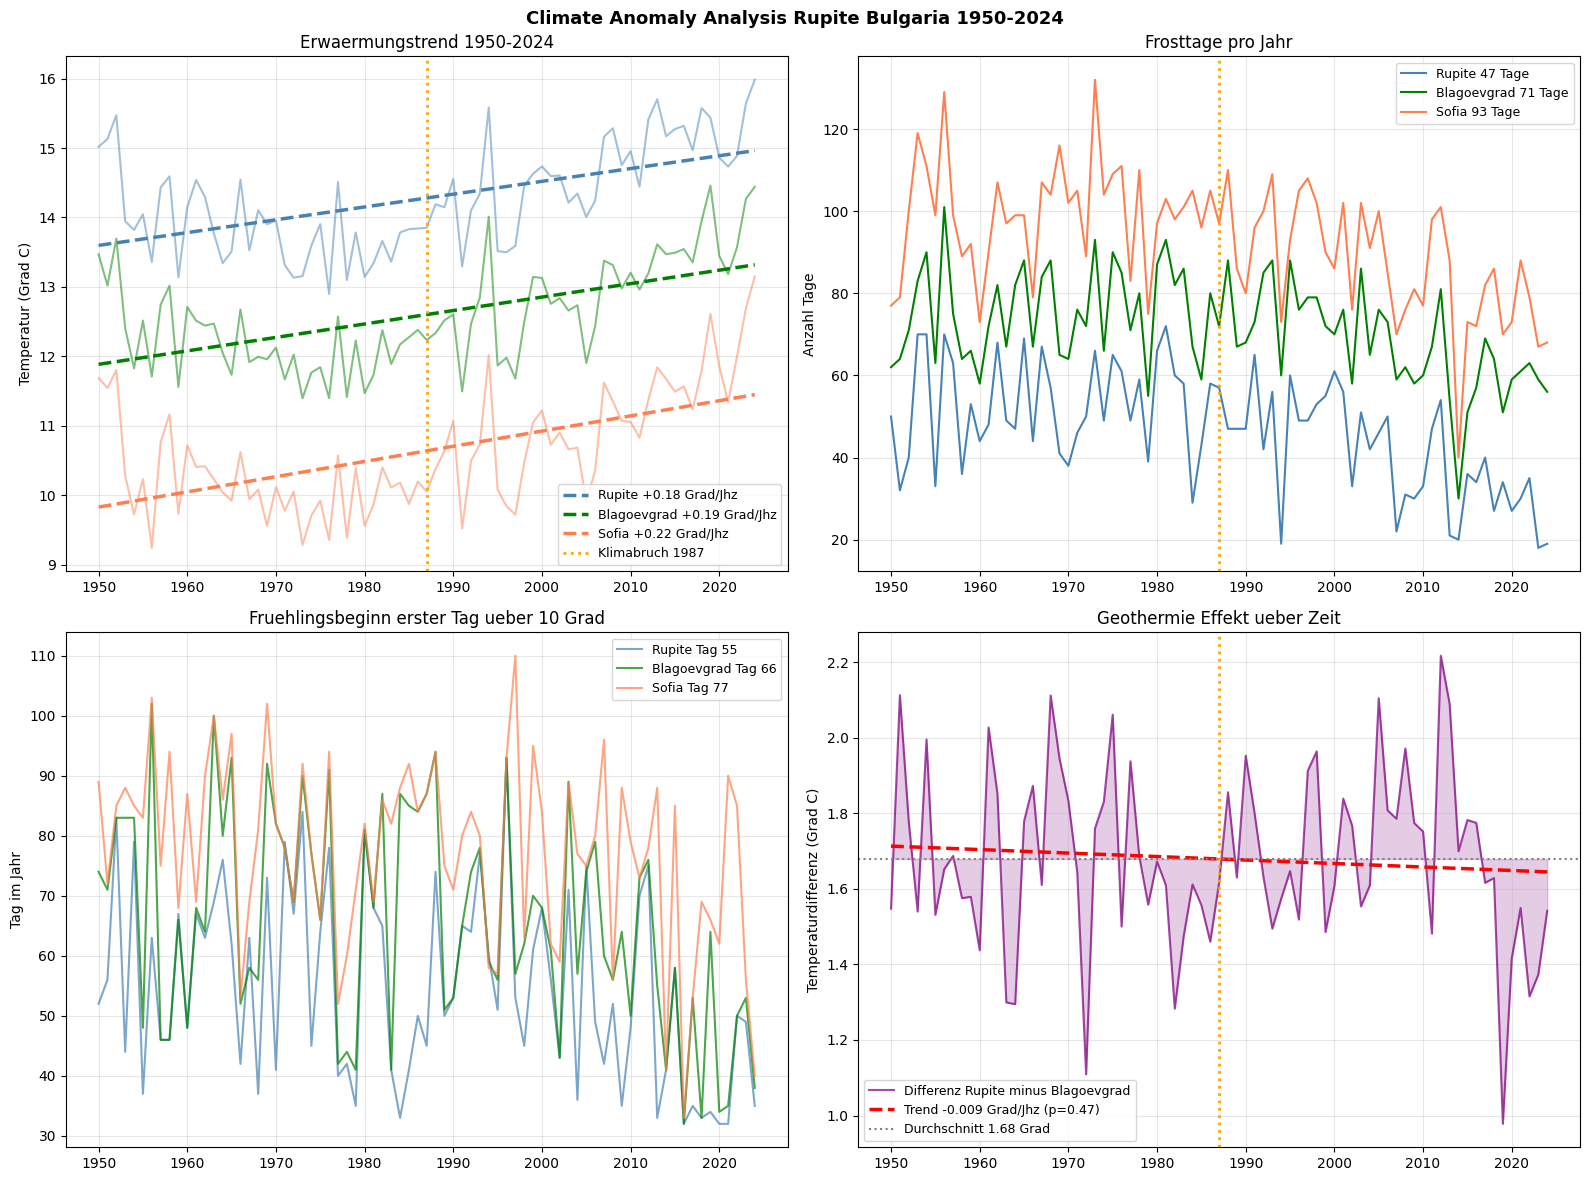

Grafik gespeichert!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(jahre_real, rupite_j["tmean"], color="steelblue", alpha=0.5)
axes[0,0].plot(jahre_real, blago_j["tmean"], color="green", alpha=0.5)
axes[0,0].plot(jahre_real, sofia_j["tmean"], color="coral", alpha=0.5)
axes[0,0].plot(jahre_real, a_r + s_r * jahre, color="steelblue", linewidth=2.5, linestyle="--", label=f"Rupite +{s_r*10:.2f} Grad/Jhz")
axes[0,0].plot(jahre_real, a_b + s_b * jahre, color="green", linewidth=2.5, linestyle="--", label=f"Blagoevgrad +{s_b*10:.2f} Grad/Jhz")
axes[0,0].plot(jahre_real, a_s + s_s * jahre, color="coral", linewidth=2.5, linestyle="--", label=f"Sofia +{s_s*10:.2f} Grad/Jhz")
axes[0,0].axvline(x=1987, color="orange", linestyle=":", linewidth=2, label="Klimabruch 1987")
axes[0,0].set_title("Erwaermungstrend 1950-2024", fontsize=12)
axes[0,0].set_ylabel("Temperatur (Grad C)")
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(jahre_real, frost_r.values, color="steelblue", linewidth=1.5, label=f"Rupite {frost_r.mean():.0f} Tage")
axes[0,1].plot(jahre_real, frost_b.values, color="green", linewidth=1.5, label=f"Blagoevgrad {frost_b.mean():.0f} Tage")
axes[0,1].plot(jahre_real, frost_s.values, color="coral", linewidth=1.5, label=f"Sofia {frost_s.mean():.0f} Tage")
axes[0,1].axvline(x=1987, color="orange", linestyle=":", linewidth=2)
axes[0,1].set_title("Frosttage pro Jahr", fontsize=12)
axes[0,1].set_ylabel("Anzahl Tage")
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(fruehling_r.index, fruehling_r["tag"], color="steelblue", linewidth=1.5, alpha=0.7, label=f"Rupite Tag {fruehling_r['tag'].mean():.0f}")
axes[1,0].plot(fruehling_b.index, fruehling_b["tag"], color="green", linewidth=1.5, alpha=0.7, label=f"Blagoevgrad Tag {fruehling_b['tag'].mean():.0f}")
axes[1,0].plot(fruehling_s.index, fruehling_s["tag"], color="coral", linewidth=1.5, alpha=0.7, label=f"Sofia Tag {fruehling_s['tag'].mean():.0f}")
axes[1,0].set_title("Fruehlingsbeginn erster Tag ueber 10 Grad", fontsize=12)
axes[1,0].set_ylabel("Tag im Jahr")
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(jahre_real, differenz, color="purple", linewidth=1.5, alpha=0.7, label="Differenz Rupite minus Blagoevgrad")
axes[1,1].plot(jahre_real, a_d + s_d * jahre, color="red", linewidth=2.5, linestyle="--", label=f"Trend {s_d*10:.3f} Grad/Jhz (p={p_d:.2f})")
axes[1,1].axhline(y=differenz.mean(), color="gray", linestyle=":", linewidth=1.5, label=f"Durchschnitt {differenz.mean():.2f} Grad")
axes[1,1].axvline(x=1987, color="orange", linestyle=":", linewidth=2)
axes[1,1].fill_between(jahre_real, differenz, differenz.mean(), alpha=0.2, color="purple")
axes[1,1].set_title("Geothermie Effekt ueber Zeit", fontsize=12)
axes[1,1].set_ylabel("Temperaturdifferenz (Grad C)")
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Climate Anomaly Analysis Rupite Bulgaria 1950-2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rupite_complete_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("Grafik gespeichert!")

In [15]:
from google.colab import files
files.download("rupite_complete_analysis.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>